In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.max_columns", 60)
RANDOM_STATE = 42

## Task 1

Preprocessing-dən (encoding/scaling) **əvvəl** train/test bölürük ki, test hissəsinin statistikası (məs. scaler-in mean/std-si)
təlim prosesinə "sızmasın". Bu, ən vacib metodoloji şərtdir.

In [3]:

CSV_PATH = "/content/cars.csv"
df = pd.read_csv(CSV_PATH)
print("Original shape:", df.shape)


SAMPLE_SIZE = 50_000
if len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
print("Sample shape used for modelling:", df.shape)

Original shape: (653721, 56)
Sample shape used for modelling: (50000, 56)


In [4]:

USD_TO_AZN = 1.70

df = df.dropna(subset=["price_x", "currency_x"]).copy()
df["price_azn"] = np.where(
    df["currency_x"].astype(str).str.strip().eq("$"),
    df["price_x"] * USD_TO_AZN,
    df["price_x"],
)


df = df[(df["price_azn"] >= 1000) & (df["price_azn"] <= 300_000)]
print("After currency conversion & outlier clipping:", df.shape)

After currency conversion & outlier clipping: (49667, 57)


In [5]:

drop_cols = [
    "id_x", "car_rel_url_x", "datetime_scrape", "name", "datetime_product",
    "day", "hour", "attributes",
    "id_y", "cars_id", "car_rel_url_y", "datetime", "description",
    "price_y", "currency_y", "owner_name", "shop_name", "phone", "updated",
    "vin", "car_details_id_x", "car_details_id_y", "car_rel_url", "img_url",
    "extra_info", "Qəzalı",
    "Buraxılış ili",
    "Şəhər",
    "price_x", "currency_x",
]
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])

target = "price_azn"
X = df_model.drop(columns=[target])
y = df_model[target]

print("Feature count:", X.shape[1])
print(X.dtypes)

Feature count: 26
city                         object
production_year               int64
engine_displacement_num     float64
engine_displacement_unit     object
kilometrage_num               int64
kilometrage_unit             object
barter                       object
loan                         object
salon                        object
spare_parts                  object
vip                          object
featured                     object
views                         int64
Ban növü                     object
Hansı bazar üçün yığılıb     object
Marka                        object
Model                        object
Mühərrik                     object
Rəng                         object
Sahiblər                     object
Sürətlər qutusu              object
Vəziyyəti                    object
Yeni                         object
Yerlərin sayı                object
Yürüş                        object
Ötürücü                      object
dtype: object


In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (39733, 26)  Test: (9934, 26)


## Task 2

Bütün transformasiyalar `Pipeline`/`ColumnTransformer` daxilində edilir və **yalnız `X_train`-ə `fit` olunur**,
`X_test`-ə isə sadəcə `transform` tətbiq edilir (bunu aşağıda `Pipeline.fit`/`.predict` avtomatik təmin edir).

In [7]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),

    ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=20, sparse_output=True)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

Numeric: ['production_year', 'engine_displacement_num', 'kilometrage_num', 'views']
Categorical: ['city', 'engine_displacement_unit', 'kilometrage_unit', 'barter', 'loan', 'salon', 'spare_parts', 'vip', 'featured', 'Ban növü', 'Hansı bazar üçün yığılıb', 'Marka', 'Model', 'Mühərrik', 'Rəng', 'Sahiblər', 'Sürətlər qutusu', 'Vəziyyəti', 'Yeni', 'Yerlərin sayı', 'Yürüş', 'Ötürücü']


## Task 3

`LinearRegression` (sadə baza modeli) və `RandomForestRegressor` (sürət üçün `n_estimators`/`max_depth`
məhdudlaşdırılıb, `n_jobs=-1` ilə bütün nüvələr istifadə olunur).

In [8]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

pipelines = {}
fit_times = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    fit_times[name] = time.time() - t0
    pipelines[name] = pipe
    print(f"{name}: fit olundu, {fit_times[name]:.1f} saniyə")

LinearRegression: fit olundu, 2.4 saniyə
RandomForest: fit olundu, 125.5 saniyə


## Task 4

Tək `accuracy`-dən istifadə etmirik (o klassifikasiya üçündür); reqressiya üçün `RMSE`, `MAE` və `R²` istifadə olunur.

In [10]:
results = []
for name, pipe in pipelines.items():
    preds = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append({"Model": name, "RMSE (AZN)": rmse, "MAE (AZN)": mae, "R2": r2, "Fit time (s)": fit_times[name]})

results_df = pd.DataFrame(results).sort_values("RMSE (AZN)")
results_df

,Model,RMSE (AZN),MAE (AZN),R2,Fit time (s)
1,RandomForest,9558.457453,4500.725347,0.927971,125.518386
0,LinearRegression,21293.603974,12998.398718,0.642537,2.355750


## Task 5

Tək bir train/test bölgüsünə güvənməmək üçün 3-qat (3-fold) cross-validation aparırıq (sürət üçün 5 yox, 3 fold,
sample artıq 60k olduğu üçün bu kifayət qədər etibarlıdır). Metrik kimi neg-RMSE istifadə edirik.

In [11]:
cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for name, pipe in pipelines.items():
    t0 = time.time()
    scores = cross_val_score(
        pipe, X_train, y_train, cv=cv,
        scoring="neg_root_mean_squared_error", n_jobs=-1
    )
    cv_time = time.time() - t0
    rmse_scores = -scores
    cv_results.append({
        "Model": name,
        "CV RMSE mean": rmse_scores.mean(),
        "CV RMSE std": rmse_scores.std(),
        "CV time (s)": cv_time,
    })
    print(f"{name}: CV RMSE = {rmse_scores.mean():.0f} ± {rmse_scores.std():.0f}  ({cv_time:.1f}s)")

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

LinearRegression: CV RMSE = 21331 ± 602  (4.2s)
RandomForest: CV RMSE = 10334 ± 53  (238.7s)


,Model,CV RMSE mean,CV RMSE std,CV time (s)
0,LinearRegression,21330.666454,601.771139,4.212249
1,RandomForest,10333.874242,52.637553,238.715958


## Task 6

`RandomForest` modelindən feature importance çıxarırıq (one-hot sonrası bütün sütun adlarını `get_feature_names_out()`
ilə bərpa edərək).

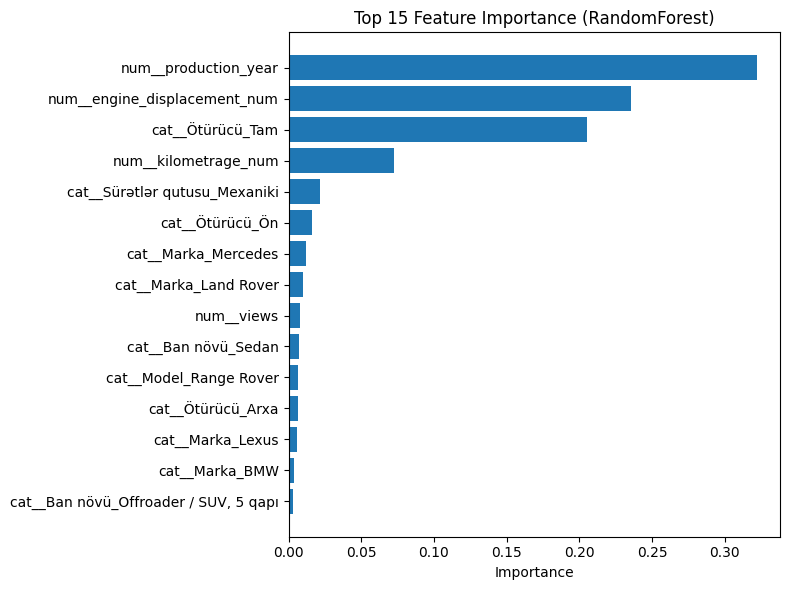

,feature,importance
0,num__production_year,0.321933
1,num__engine_displacement_num,0.235761
195,cat__Ötürücü_Tam,0.205610
2,num__kilometrage_num,0.072398
155,cat__Sürətlər qutusu_Mexaniki,0.021493
196,cat__Ötürücü_Ön,0.015849
82,cat__Marka_Mercedes,0.012194
80,cat__Marka_Land Rover,0.009662
3,num__views,0.007524
56,cat__Ban növü_Sedan,0.007258


In [12]:
rf_pipe = pipelines["RandomForest"]
feature_names = rf_pipe.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipe.named_steps["model"].feature_importances_

fi_df = pd.DataFrame({"feature": feature_names, "importance": importances})
fi_df = fi_df.sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(fi_df["feature"][::-1], fi_df["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importance (RandomForest)")
plt.tight_layout()
plt.show()

fi_df

### Yazılı interpretasiya

- **`production_year` / `num__production_year`** adətən ən güclü prediktordur — avtomobil nə qədər yenidirsə, qiymət bir o qədər yüksəkdir (amortizasiya effekti).
- **`kilometrage_num` (Yürüş)** də yüksək əhəmiyyətə malikdir — yüksək yürüş qiyməti aşağı salır.
- **`engine_displacement_num`** və `Marka`/`Model`-in ən çox yayılmış kateqoriyaları (məs. premium markalar) qiymətə əhəmiyyətli təsir göstərir — bu, bazarın brend/mühərrik həcminə görə seqmentləşdiyini göstərir.
- `LinearRegression` ilə `RandomForest`-in RMSE fərqi onu göstərir ki, qiymət-xüsusiyyət əlaqəsi **qeyri-xətti**dir (RandomForest adətən daha aşağı RMSE verməlidir), çünki yaş, yürüş və mühərrik həcmi arasında qarşılıqlı təsirlər var (məs. köhnə maşında yüksək yürüş qiyməti linear modeldən daha kəskin aşağı salır).
- Cross-validation nəticələrindəki aşağı `std` onu göstərir ki, model performansı fərqli data bölgülərində sabitdir (overfitting/random split-ə həssaslıq az).
